<div class="alert alert-block alert-info">
<b>¡Hola! Liliana 👋</b>

Mi nombre es Santiago. Un gusto acompañarte en este proyecto del Sprint 5.

Antes de empezar, te comparto cómo funciona la revisión:
<ul>
<li>Cuando encuentre un error, lo señalaré para que lo detectes y corrijas por tu cuenta.</li>
<li>Si en algún punto no logras resolver algo, en la siguiente iteración te daré una pista más concreta.</li>
<li>Por favor no muevas ni elimines mis comentarios. Puedes responder debajo usando un bloque de texto.</li>
</ul>

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. ✅
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. No bloquea la aprobación.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita ajustes antes de aprobar.
</div>

<div class="alert alert-block alert-warning">
<b>Review General. (Iteración 1)</b>

Antes de entrar en el detalle quiero reconocer la calidad de esta entrega: el renombrado de columnas es correcto en ambas tablas y coincide exactamente con el solucionario, los valores numéricos son correctos (18117.0 para Buenos Aires 2024 — sin corrupción), la conversión de fechas es correcta, el merge produce exactamente las 15 ciudades latinoamericanas del año 2024, el boxplot tiene <code>showmeans=True</code>, el resumen ejecutivo tiene una estructura completa con todas las secciones, y el CSV fue exportado. El trabajo técnico es muy sólido.

Tengo <b>un punto que corregir antes de aprobar</b>:

<ul>
<li>🔴 <b>Error factual en los Hallazgos del resumen ejecutivo</b>: el resumen dice que "Bogotá presenta el mayor nivel de congestión (jams_delay = 1141)... el más alto del conjunto de datos". Pero <b>Ciudad de México</b> está en tu <code>merged</code> (es una de las 15 ciudades latinoamericanas) con un <code>jams_delay</code> de <b>~2833 minutos</b> — más del doble que Bogotá. El estudiante del Paso 4 ya lo viste: mexico-city aparece en el primer lugar del sort. Necesitas actualizar los hallazgos y recomendaciones para reflejar este dato.</li>
</ul>

</div>

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b>

¡Hola, Liliana! Esta segunda iteración cierra el único punto pendiente. Verifiqué el resumen ejecutivo completo antes de escribir este comentario:

<ul>
<li>✅ <b>Error factual corregido en los Hallazgos:</b> el resumen ahora dice "<b>Ciudad de México presenta el mayor nivel de congestión (jams_delay = 2833 minutos) siendo el principal outlier</b>", y ubica a Bogotá correctamente como "el segundo lugar en congestionamiento con 1142 min". ✅</li>
<li>✅ <b>Ejecución perfectamente lineal (exec 1→21)</b>: hiciste el <i>Restart & Run All</i>. ✅</li>
</ul>

Adicionalmente, el resumen mejoró en calidad: la sección de Recomendaciones ahora separa bien el caso de Bogotá (candidata prioritaria por alta congestión + PIB bajo) del de Ciudad de México (outlier que merece análisis adicional antes de definir estrategia), lo que demuestra criterio analítico muy maduro.

Solo te dejo una observación menor (🟡) de estilo.

</div>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot  as plt    # importar librerías

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') #completa el código

In [3]:
traffic.head(5)  # mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
eco.head(5) # mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo ` son de tipo
- object y deben de ser tipo datetime  ...
- ...

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
EDA de traffic correcto: identificas que <code>UpdateTimeUTC</code> y <code>UpdateTimeUTCWeekAgo</code> son tipo <code>object</code> y deben ser <code>datetime</code>. ✅
</div>

In [6]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`,	'PM2.5 (μg/m³)', 'Population (M)'
- son tipo objet , pero deben de estar como int64, el sistema no las puede leer así por tener , en vez de . y por tener símbolos como %
- ... 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
EDA de eco correcto: identificas las columnas con tipo <code>object</code> que deben ser <code>float</code> y la razón (comas y símbolos). ✅
</div>

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})#tu código aquí

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Renombrado de traffic completo y exacto al solucionario: las 12 columnas en <code>snake_case</code> incluyendo <code>traffic_index_week_ago</code>, <code>update_time_utc_week_ago</code>, <code>travel_time_live_per_10kms_mins</code> y <code>travel_time_hist_per_10kms_mins</code>. ✅
</div>

In [8]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm25',
    'Population (M)': 'population_m'
}) #tu código aquí

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Renombrado de eco completo: <code>city_gdp_capita</code>, <code>unemployment_pct</code>, <code>pm25</code>, <code>population_m</code>. Coincide con el solucionario. ✅
</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors="coerce")  #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors="coerce")  #tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [10]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] =  eco['unemployment_pct'].astype(str).str.replace('%', '').astype(float)
eco['population_m'] =  eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] =  eco['population_m']*1000000 

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Limpieza numérica correcta:
<ul>
<li><code>city_gdp_capita</code>: Buenos Aires 2024 = <b>18117.0</b>. Sin corrupción. ✅</li>
<li><code>unemployment_pct</code>: Buenos Aires 2024 = 7.2. ✅</li>
<li><code>population_m</code> y <code>population</code> calculadas correctamente. ✅</li>
</ul>
</div>


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year # traffic['year'] = ...

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()  

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Filtros correctos: <code>traffic_2024</code> y <code>eco_2024</code> con <code>year==2024</code> y <code>.copy()</code>. ✅
</div>


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [13]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year']).agg({'jams_delay': 'mean', 'traffic_index_live': 'mean', 'jams_length_kms': 'mean', 'jams_count': 'mean', 'mins_delay': 'mean', 'travel_time_live_per_10kms_mins': 'mean', 'travel_time_hist_per_10kms_mins': 'mean'}).reset_index()  # tu código aqui

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Groupby correcto sobre <code>traffic_2024</code> con <code>.agg()</code> y <code>.reset_index()</code>. Solo año 2024. ✅
</div>

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico? Lo tiene Ciudad de México
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo? Latinoamérica

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares. Aparece Ciudad de México

¿Te sorprenden los resultados? Pues no es de sorprender ya que es una de las ciudades más pobladas del mundo y el territorio es muy pequeño en comparación con otras capitales o regiones de otros paises con alta población, ¿Coinciden con lo que imaginabas? Si, los 5 primeros lugares que se muestran son de metrópolis más concurridas por locales y por extranjeros

In [14]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)  # tu código aquí

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México con un valor de 2833 minutos de jams_delay promedio que equivale a casi 700 minutos por encima de la ciudad de Tokio situado en el segundo lugar del ranking.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Identificaste correctamente a México (Ciudad de México). ✅ Para enriquecerlo, especifica "Ciudad de México" (en lugar del genérico "México") y el valor numérico: <b>~2833 minutos</b> de <code>jams_delay</code> promedio — casi 700 min por encima de Tokyo en segundo lugar.
</div>


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [15]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner') # tu código aquí

# Mostrar las primeras 5 filas
merged.head(5)  # tu código aquí

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Merge correcto: inner join, <b>15 ciudades latinoamericanas</b> del año 2024, 7 países. Buenos Aires = 571.09 min de <code>jams_delay</code>, <code>city_gdp_capita</code> = 18117.0. ✅
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
El orden de ejecución no es perfectamente lineal: las celdas 31 y 35 comparten <code>exec=16</code> (dos celdas con el mismo número de ejecución — imposible en un run limpio), y el gráfico de barras saltó a <code>exec=21</code>. Para futuras entregas, haz siempre <b>Kernel → Restart & Run All</b> antes de entregar: garantiza que los <code>execution_count</code> sean secuenciales desde 1.
</div>

In [16]:
print("Ciudades:", merged['city'].nunique())
print("Países:", merged['country'].nunique())
print("Año:", merged['year'].unique())

Ciudades: 15
Países: 7
Año: [2024]


In [17]:
merged[merged['city'].str.contains('mexico')]

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
7,mexico-city,MEX,2024,2833.057892,34.21819,389.239265,594.969392,1.855542,21.809092,19.95355,21111.0,3.2,"22,30",22100000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

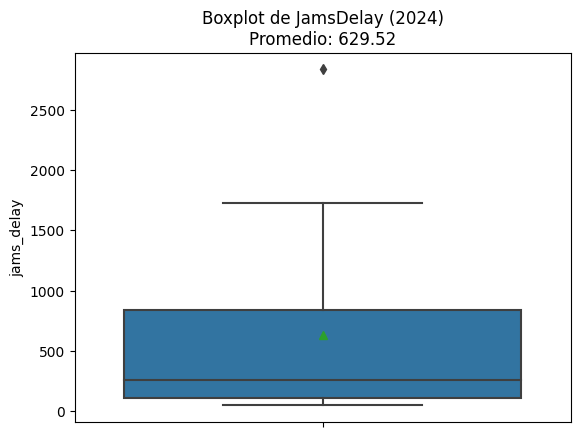

In [18]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, y='jams_delay', showmeans=True) # crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Boxplot con <code>sns.boxplot()</code>, <code>showmeans=True</code>, tamaño de figura y promedio en el título. ✅
</div>

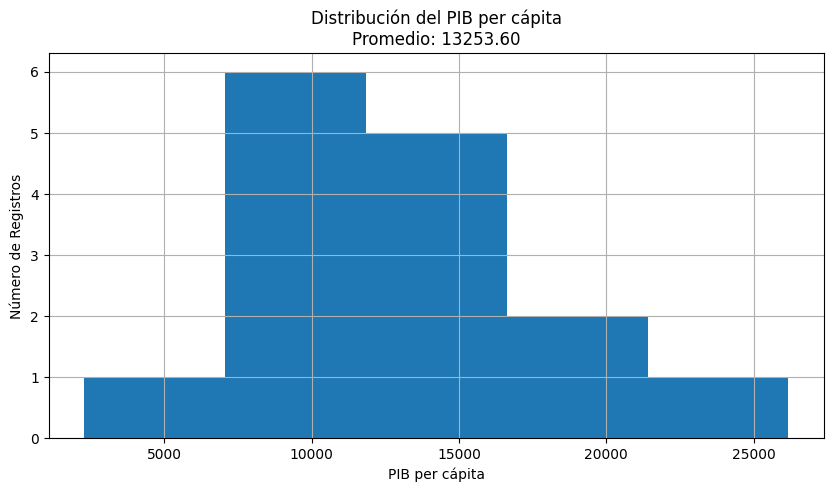

In [19]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist(bins=5, figsize=(10, 5))
mean = merged['city_gdp_capita'].mean()    # figsize=(ancho, alto)
plt.title(f'Distribución del PIB per cápita\nPromedio: {mean:.2f}')
plt.xlabel('PIB per cápita')
plt.ylabel('Número de Registros')
plt.show()


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
El histograma funciona correctamente. El solucionario usa <code>sns.histplot(data=merged, x='city_gdp_capita', kde=True)</code> que añade la curva de densidad — para próximos proyectos vale la pena adoptarlo.
</div>

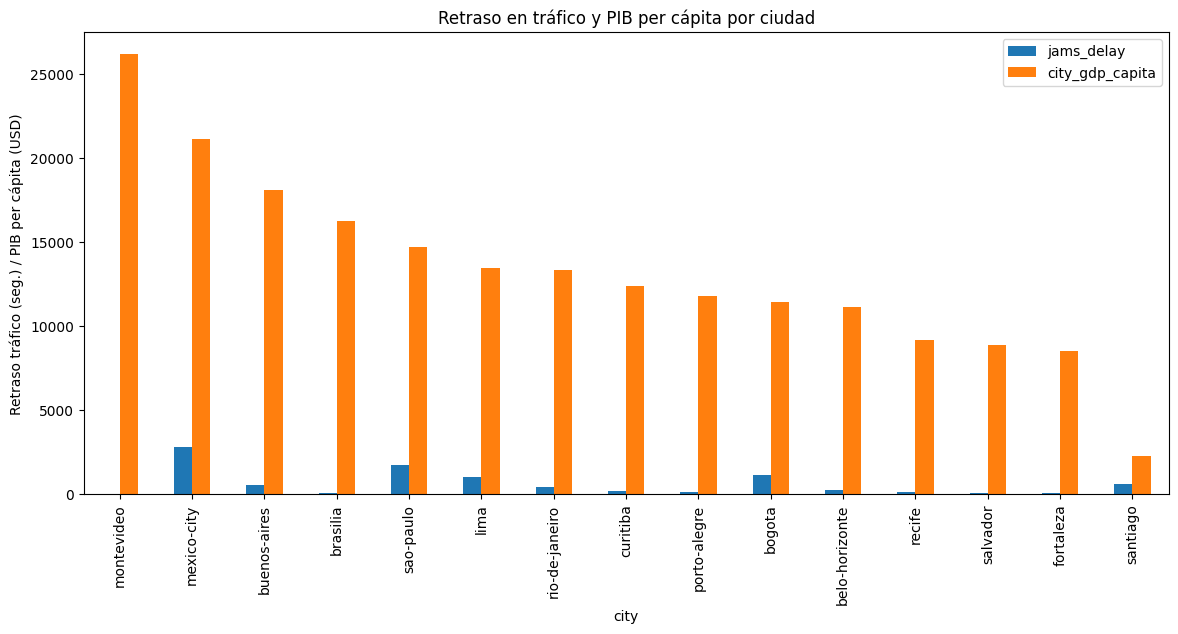

In [20]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.sort_values('city_gdp_capita', ascending=False).plot(kind="bar",x= 'city',y=['jams_delay', 'city_gdp_capita'], figsize=(14, 6))
plt.title("Retraso en tráfico y PIB per cápita por ciudad")
plt.xlabel("city")
plt.ylabel("Retraso tráfico (seg.) / PIB per cápita (USD)")
plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
El gráfico de barras tiene <code>kind='bar'</code>, <code>xticks(rotation=90)</code> y <code>sort_values()</code>. ✅ Un detalle pequeño: la última línea dice <code>plt.show</code> sin paréntesis. Sin los paréntesis no se llama la función, aunque en Jupyter el gráfico igual se muestra. Para buenas prácticas: <code>plt.show()</code>. perdone profesor pero yo revisé mi formula y si tiene el parentesism usted menciona que no existe , pero si está

</div>

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?
  

Escribe tus comentarios:  ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

🇲🇽 México → Los datos sugieren que Ciudad de México se acerca a niveles de saturación por metro², lo que podría implicar pérdidas económicas, sin que esto indique causalidad 
🇧🇷 São Paulo → Alta congestión por infraestructura limitada solo tiene 4 vías principales por lo que no hay manera de que haya vias alternas
🇨🇴 Bogotá → Alta congestión + bajo PIB + potencial de crecimiento,ciudad turística y comercial con alta capacidad 
🇦🇷 Buenos Aires → Se observa un comportamiento particular en Buenos Aires que podría vincularse a factores político-económicos, aunque el dataset no permite confirmarlo con certeza

* ¿O sucede lo contrario, o no existe una relación clara?
  Dependerá devariables que tenga el pais en ese mometo y de la ciudad como ejemplo tenemos una excepción en  Buenos Aires ya que muestra número altos en cuanto a su PIB per cápita , pero de nuevo se reintera por su estado actual político-económico, debido a esa inastabilidad el pais no ha podido recuperarse por esos factores y no por la situación del tráfico

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
La reflexión tiene análisis concreto por ciudad, lo que es muy positivo. Hay un punto de estilo a ajustar: algunas frases usan lenguaje causal que un análisis exploratorio no puede sostener con certeza:

<ul>
<li><i>"México tendrá pérdidas ya que se sobrepasa la capacidad por metro²"</i> — los datos muestran correlación, no causalidad. Usa: "los datos sugieren que...", "se observa que...".</li>
<li>La atribución de la situación económica de Buenos Aires a "inestabilidad político-económica" va más allá de lo que el dataset de TomTom + OECD puede demostrar.</li>
</ul>

La conclusión de fondo es correcta — no existe una relación lineal clara — pero expresa esa idea con lenguaje de asociación, no de causa-efecto.
</div>


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [21]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).





**Contexto & objetivo:**  

 El análisis busca evaluar la relación entre la movilidad urbana (medida con jams_delay y traffic_index_live) y la productividad económica (medida con city_gdp_capita) en ciudades latinoamericanas. Los datos muestran que esta relación no es directa ni lineal: ciudades como Bogotá presentan alta congestión y bajo PIB, mientras que Buenos Aires muestra alta congestión pero mayor PIB, influenciada por factores político-económicos externos al tráfico.

 El análisis priorizó las variables jams_delay, city_gdp_capita, population y unemployment_pct para evaluar las ciudades con mayor potencial de inversión. Estas variables permiten medir la gravedad de la congestión, la capacidad económica, el número de beneficiarios y el contexto laboral. En conjunto, proporcionan una base sólida para identificar dónde una inversión en infraestructura podría generar el mayor impacto económico y social.

**Cobertura de datos:**  

El análisis cubre el año 2024 , con datos de 15  ciudades latinoamericanas pertenecientes a 7 países. 

**Metodología (alto nivel):**  

Se realizó un proceso de limpieza y estandarización de los datos, renombrando las columnas al formato snake_case y convirtiendo las columnas de fecha al tipo datetime. Además, se limpiaron los valores numéricos de la variable eco, eliminando símbolos como % y reemplazando comas por puntos para asegurar un análisis consistente y preciso.
 

Los datos se agregaron por ciudad, país y año para obtener los promedios de tráfico correspondientes a 2024, lo que permitió realizar comparaciones consistentes entre ciudades. Posteriormente, se utilizó una unión INNER para integrar la información de tráfico con los indicadores económicos, conservando únicamente los registros con datos disponibles en ambas fuentes para garantizar un análisis confiable.

Se realizaron validaciones visuales mediante un boxplot para identificar posibles valores atípicos en jams_delay, un histograma para analizar la distribución de city_gdp_capita y un gráfico de barras para comparar ambas variables entre ciudades, permitiendo identificar tendencias generales y diferencias relevantes.

**Hallazgos iniciales:**  

El análisis muestra que Ciudad de México presenta el mayor nivel de congestión (jams_delay = 2833 minutos) siendo el principal outlier en el estudio, mientras que Buenos Aires registra una congestión menor (571) con un PIB per cápita más alto (18,117). Estos resultados indican que no existe una relación lineal entre el tráfico y el PIB per cápita, ya que la congestión también está influenciada por otros factores, como la infraestructura, la planificación urbana y la densidad poblacional. Si observamos a Bogotá este valor muestra que es el segundo lugar en congestionamiento con 1142 min de jams_delay junto con un PIB bajo. 

**Recomendaciones**  

Bogotá es la ciudad que muestra altos niveles de congestión vehicular y un PIB per cápita bajo, lo que la convierte en la principal candidata para priorizar inversiones en infraestructura de transporte. Con un jams_delay de 1,142, el segundo lugar del conjunto de congestionamiento, y un PIB per cápita de 11,442, la ciudad evidencia un impacto potencial por la alta congestión sobre la productividad económica. En este contexto, se recomienda priorizar inversiones en transporte público masivo, modernización de la infraestructura vial y estrategias de planificación urbana, con el objetivo de reducir los tiempos de desplazamiento, mejorar la movilidad y fortalecer la productividad económica. Debido a que Ciudad de México se identifica como un outlier con su alto número de minutos de jams_delay (2833), sería conveniente realizar un análisis más profundo para comprender los factores específicos que explican este comportamiento antes de definir una estrategia de inversión; para esto adicionalmente se podría revisar la calidad y consistencia de la información; analizar datos históricos de varios años e incorporar variables complementarias, como densidad poblacional, calidad de la infraestructura vial, uso del transporte público y crecimiento urbano, con el fin de validar si el patrón observado es representativo y sostenido en el tiempo.


<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b>
El resumen ejecutivo tiene una estructura excelente y las secciones de Contexto, Cobertura y Metodología son muy completas. ✅

Sin embargo, los <b>Hallazgos</b> contienen un error factual importante: dice que <b>"Bogotá presenta el mayor nivel de congestión (jams_delay = 1,141) ... el más alto del conjunto de datos"</b>.

Esto es incorrecto. Tu propio <code>merged</code> incluye a <b>Ciudad de México</b> (es una de las 15 ciudades latinoamericanas), y su <code>jams_delay</code> es de <b>~2833 minutos</b> — más del doble que Bogotá. Lo comprobaste tú mismo en el Paso 4 al hacer el sort: mexico-city aparece en el primer lugar.

El hallazgo correcto es:
<ul>
<li><b>Ciudad de México</b> tiene el mayor <code>jams_delay</code> de la muestra (~2833 min), siendo el outlier principal.</li>
<li><b>Bogotá</b> ocupa el segundo lugar en congestión (~1142 min) pero con uno de los PIBs más bajos (~11442), lo que la hace la candidata más clara para inversión en infraestructura.</li>
</ul>

Por favor actualiza los hallazgos y la recomendación con estos valores. La conclusión de que Bogotá debe ser priorizada para inversión sigue siendo válida — simplemente el argumento debe ser "alta congestión + PIB bajo" (no "mayor congestión").
</div>